<a href="https://colab.research.google.com/github/queleandrade/INTELIG-NCIA-COMPUTACIONAL-APLICADA-ENGENHARIA-Mestrado/blob/main/adaline_valvulas_quele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Prático: ADALINE – Classificação de Sinais de Válvulas Industriais
**Disciplina:** Inteligência Computacional Aplicada à Engenharia  
**Profs.:** André Ottoni e José Valentim

---
**Problema:** Um sistema industrial transmite sinais `{x1, x2, x3, x4}` por via única.  
O ADALINE classifica cada sinal como **Válvula A (d = −1)** ou **Válvula B (d = +1)**.  

**Parâmetros:** η = 0,0025 | ε = 10⁻⁶ | Critério de parada: |EQM(t) − EQM(t−1)| < ε

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Conjunto de Treinamento – Apêndice II (Seção 4.6)
Fonte: da Silva, Spatti & Flauzino (2016) – 35 amostras, 4 entradas.  
Convenção: **−1 → Válvula A** | **+1 → Válvula B**

In [ ]:
# Apêndice II – 35 amostras com ruído (seção 4.6)
dados = np.array([
    #  x1       x2       x3       x4       d
    [ 0.4329, -1.3719,  0.7022, -0.8535,  1.0],  # 01
    [ 0.3024,  0.2286,  0.8630,  2.7909, -1.0],  # 02
    [ 0.1349, -0.6445,  1.0530,  0.5687, -1.0],  # 03
    [ 0.3374, -1.7163,  0.3670, -0.6283, -1.0],  # 04
    [ 1.1434, -0.0485,  0.6637,  1.2606,  1.0],  # 05
    [ 1.3749, -0.5071,  0.4464,  1.3009,  1.0],  # 06
    [ 0.7221, -0.7587,  0.7681, -0.5592,  1.0],  # 07
    [ 0.4403, -0.8072,  0.5154, -0.3129,  1.0],  # 08
    [-0.5231,  0.3548,  0.2538,  1.5776, -1.0],  # 09
    [ 0.3255, -2.0000,  0.7112, -1.1209,  1.0],  # 10
    [ 0.5824,  1.3915, -0.2291,  4.1735, -1.0],  # 11
    [ 0.1340,  0.6081,  0.4450,  3.2230, -1.0],  # 12
    [ 0.1480, -0.2988,  0.4778,  0.8649,  1.0],  # 13
    [ 0.7359,  0.1869, -0.0872,  2.3584,  1.0],  # 14
    [ 0.7115, -1.1469,  0.3394,  0.9573, -1.0],  # 15
    [ 0.8251, -1.2840,  0.8452,  1.2382, -1.0],  # 16
    [ 0.1569,  0.3712,  0.8825,  1.7633,  1.0],  # 17
    [ 0.0033,  0.6835,  0.5389,  2.8249, -1.0],  # 18
    [ 0.4243,  0.8313,  0.2634,  3.5855, -1.0],  # 19
    [ 1.0490,  0.1326,  0.9138,  1.9792,  1.0],  # 20
    [ 1.4276,  0.5331, -0.0145,  3.7286,  1.0],  # 21
    [ 0.5971,  1.4865,  0.2904,  4.0690, -1.0],  # 22
    [ 0.8475,  2.1479,  0.3179,  5.8235, -1.0],  # 23
    [ 1.3967, -0.4171,  0.6443,  1.3927,  1.0],  # 24
    [ 0.0044,  1.5378,  0.6099,  4.7755, -1.0],  # 25
    [ 0.2201, -0.5668,  0.8591,  0.7829,  1.0],  # 26
    [ 0.6300, -1.2480,  0.8591,  0.8093, -1.0],  # 27
    [-0.2479,  0.8960,  0.0547,  1.7381,  1.0],  # 28
    [-0.3088, -0.0929,  0.8659,  1.5483, -1.0],  # 29
    [-0.5180,  1.4974,  0.5453,  2.3993,  1.0],  # 30
    [ 0.6833,  0.8266,  0.0829,  2.8864,  1.0],  # 31
    [ 0.4353, -1.4066,  0.4207, -0.4879,  1.0],  # 32
    [-0.1069, -3.2329,  0.1856, -2.4572, -1.0],  # 33
    [ 0.4662,  0.6261,  0.7304,  3.4370, -1.0],  # 34
    [ 0.8298, -1.4089,  0.3119,  1.3235, -1.0],  # 35
])

X_raw = dados[:, :4]
d     = dados[:, 4].astype(int)
N     = len(d)

# Bias x0 = +1 como primeira coluna (θ = w0, convenção da Figura 2)
X = np.hstack([np.ones((N, 1)), X_raw])

print(f"Amostras: {N} | Válvula A (−1): {(d==-1).sum()} | Válvula B (+1): {(d==1).sum()}")
df = pd.DataFrame(X_raw, columns=['x1','x2','x3','x4'],
                  index=[f"{i+1:02d}" for i in range(N)])
df['d'] = d
print(df.to_string())

Amostras: 35 | Válvula A (−1): 18 | Válvula B (+1): 17
        x1      x2      x3      x4  d
01  0.4329 -1.3719  0.7022 -0.8535  1
02  0.3024  0.2286  0.8630  2.7909 -1
03  0.1349 -0.6445  1.0530  0.5687 -1
04  0.3374 -1.7163  0.3670 -0.6283 -1
05  1.1434 -0.0485  0.6637  1.2606  1
06  1.3749 -0.5071  0.4464  1.3009  1
07  0.7221 -0.7587  0.7681 -0.5592  1
08  0.4403 -0.8072  0.5154 -0.3129  1
09 -0.5231  0.3548  0.2538  1.5776 -1
10  0.3255 -2.0000  0.7112 -1.1209  1
11  0.5824  1.3915 -0.2291  4.1735 -1
12  0.1340  0.6081  0.4450  3.2230 -1
13  0.1480 -0.2988  0.4778  0.8649  1
14  0.7359  0.1869 -0.0872  2.3584  1
15  0.7115 -1.1469  0.3394  0.9573 -1
16  0.8251 -1.2840  0.8452  1.2382 -1
17  0.1569  0.3712  0.8825  1.7633  1
18  0.0033  0.6835  0.5389  2.8249 -1
19  0.4243  0.8313  0.2634  3.5855 -1
20  1.0490  0.1326  0.9138  1.9792  1
21  1.4276  0.5331 -0.0145  3.7286  1
22  0.5971  1.4865  0.2904  4.0690 -1
23  0.8475  2.1479  0.3179  5.8235 -1
24  1.3967 -0.4171  0.6443  1.392

## Hiperparâmetros

In [ ]:
eta        = 0.0025   # taxa de aprendizado
epsilon    = 1e-6     # precisão (critério de parada)
max_epocas = 10000    # limite de segurança

## Função de Treinamento ADALINE
Critério de parada: variação do EQM entre épocas → |EQM(t) − EQM(t−1)| < ε

In [ ]:
def treinar_adaline(X, d, eta, epsilon, max_epocas, seed):
    """Treina ADALINE online (Regra Delta). Para quando |ΔEQM| < epsilon."""
    np.random.seed(seed)
    w = np.random.uniform(0, 1, X.shape[1])   # pesos iniciais aleatórios em [0, 1]
    w_inicial    = w.copy()
    hist_eqm     = []
    eqm_anterior = np.inf

    for ep in range(1, max_epocas + 1):
        soma_eq = 0.0
        for i in range(len(d)):
            y_net  = np.dot(w, X[i])       # saída linear (potencial u)
            erro   = d[i] - y_net          # erro contínuo (Regra Delta)
            w     += eta * erro * X[i]     # atualização: Δw = η·e·x
            soma_eq += erro ** 2

        eqm = soma_eq / len(d)
        hist_eqm.append(eqm)

        if abs(eqm - eqm_anterior) < epsilon:
            break
        eqm_anterior = eqm

    return w_inicial, w, hist_eqm, ep

## Questão 1 – Cinco Treinamentos com Pesos Iniciais Distintos

In [ ]:
seeds = [10, 20, 30, 40, 50]   # seed diferente → pesos iniciais diferentes
resultados = []

print("Treinamento ADALINE – 5 execuções")
print("=" * 70)

for i, seed in enumerate(seeds, 1):
    w_ini, w_fim, hist_eqm, epocas = treinar_adaline(
        X, d, eta, epsilon, max_epocas, seed
    )
    resultados.append({
        'T'        : i,
        'w_inicial': w_ini,
        'w_final'  : w_fim,
        'epocas'   : epocas,
        'eqm_hist' : hist_eqm,
        'eqm_final': hist_eqm[-1]
    })
    print(f"T{i} | seed={seed} | épocas={epocas:5d} | EQM={hist_eqm[-1]:.6f}")
    print(f"   w_ini = [{', '.join(f'{v:.4f}' for v in w_ini)}]")
    print(f"   w_fim = [{', '.join(f'{v:.4f}' for v in w_fim)}]")
    print()

Treinamento ADALINE – 5 execuções
T1 | seed=10 | épocas=  831 | EQM=0.350132
   w_ini = [0.7713, 0.0208, 0.6336, 0.7488, 0.4985]
   w_fim = [1.6357, 1.2855, 1.5948, -0.1695, -1.1508]

T2 | seed=20 | épocas=  819 | EQM=0.350132
   w_ini = [0.5881, 0.8977, 0.8915, 0.8158, 0.0359]
   w_fim = [1.6356, 1.2857, 1.5950, -0.1691, -1.1509]

T3 | seed=30 | épocas=  814 | EQM=0.350132
   w_ini = [0.6441, 0.3807, 0.6630, 0.1637, 0.9626]
   w_fim = [1.6357, 1.2854, 1.5946, -0.1698, -1.1507]

T4 | seed=40 | épocas=  826 | EQM=0.350132
   w_ini = [0.4077, 0.0554, 0.7885, 0.2873, 0.4504]
   w_fim = [1.6358, 1.2855, 1.5948, -0.1697, -1.1508]

T5 | seed=50 | épocas=  841 | EQM=0.350132
   w_ini = [0.4946, 0.2281, 0.2555, 0.3963, 0.3773]
   w_fim = [1.6356, 1.2855, 1.5947, -0.1696, -1.1508]



## Questão 2 – Tabela de Resultados dos Cinco Treinamentos

In [ ]:
linhas = []
for r in resultados:
    linha = {f'w{j}_ini': round(r['w_inicial'][j], 4) for j in range(5)}
    linha.update({f'w{j}_fim': round(r['w_final'][j], 4) for j in range(5)})
    linha['Épocas'] = r['epocas']
    linhas.append(linha)

df_tab = pd.DataFrame(
    linhas,
    index=[f"T{r['T']}" for r in resultados],
    columns=[
        'w0_ini','w1_ini','w2_ini','w3_ini','w4_ini',
        'w0_fim','w1_fim','w2_fim','w3_fim','w4_fim','Épocas'
    ]
)

print("Tabela 1 – Resultados dos Treinamentos do ADALINE")
print("=" * 100)
print(df_tab.to_string())

Tabela 1 – Resultados dos Treinamentos do ADALINE
    w0_ini  w1_ini  w2_ini  w3_ini  w4_ini  w0_fim  w1_fim  w2_fim  w3_fim  w4_fim  Épocas
T1  0.7713  0.0208  0.6336  0.7488  0.4985  1.6357  1.2855  1.5948 -0.1695 -1.1508     831
T2  0.5881  0.8977  0.8915  0.8158  0.0359  1.6356  1.2857  1.5950 -0.1691 -1.1509     819
T3  0.6441  0.3807  0.6630  0.1637  0.9626  1.6357  1.2854  1.5946 -0.1698 -1.1507     814
T4  0.4077  0.0554  0.7885  0.2873  0.4504  1.6358  1.2855  1.5948 -0.1697 -1.1508     826
T5  0.4946  0.2281  0.2555  0.3963  0.3773  1.6356  1.2855  1.5947 -0.1696 -1.1508     841


## Questão 3 – Gráficos EQM × Época (T1 e T2) e Análise de Separabilidade

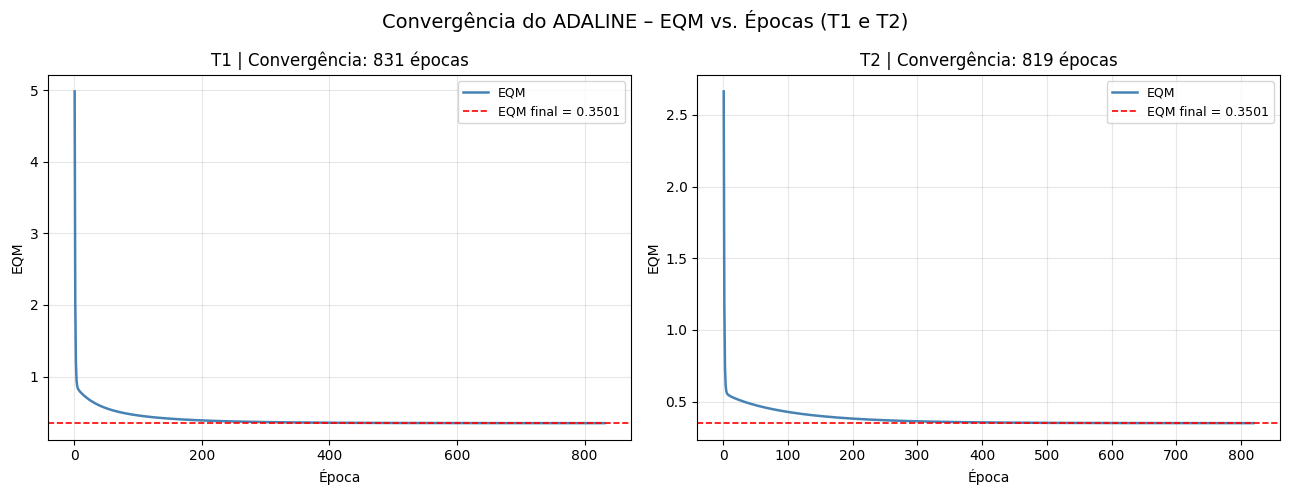

Gráfico salvo: convergencia_T1_T2.png


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

for idx in range(2):
    r = resultados[idx]
    ep_vec = np.arange(1, r['epocas'] + 1)

    axs[idx].plot(ep_vec, r['eqm_hist'], linewidth=1.8, color='steelblue', label='EQM')
    axs[idx].axhline(y=r['eqm_final'], color='red', linestyle='--', linewidth=1.2,
                     label=f"EQM final = {r['eqm_final']:.4f}")
    axs[idx].set_title(f'T{idx+1} | Convergência: {r["epocas"]} épocas', fontsize=12)
    axs[idx].set_xlabel('Época')
    axs[idx].set_ylabel('EQM')
    axs[idx].legend(fontsize=9)
    axs[idx].grid(True, alpha=0.3)

plt.suptitle('Convergência do ADALINE – EQM vs. Épocas (T1 e T2)', fontsize=14)
plt.tight_layout()
plt.savefig('convergencia_T1_T2.png', dpi=150)
plt.show()
print("Gráfico salvo: convergencia_T1_T2.png")

### Análise – Comportamento dos Gráficos e Separabilidade Linear

**T1 vs T2:** Ambos exibem queda monotônica do EQM até um platô onde |ΔEQM| < ε = 10⁻⁶.
O número de épocas difere entre treinamentos pois os pesos iniciais são distintos;
inicializações mais próximas da solução ótima reduzem as iterações necessárias.
Os pesos finais convergem para valores muito próximos em todos os cinco treinamentos,
evidenciando que a superfície de erro possui um único mínimo global (função quadrática convexa).

**Separabilidade linear:** O EQM residual (~0,35) é maior que zero porque o sistema é
sobredeterminado (35 amostras, 5 pesos) e os sinais contêm ruído intrínseco do canal.
Ainda assim, a acurácia de classificação próxima de 94% indica que as classes são
**aproximadamente linearmente separáveis**, justificando o uso do ADALINE neste problema.
A convergência consistente dos pesos finais, independentemente da inicialização, reforça
essa conclusão.

In [ ]:
# Acurácia de classificação no conjunto de treinamento
print("Acurácia no conjunto de treinamento:")
for r in resultados:
    pred = np.where(X @ r['w_final'] >= 0, 1, -1)
    acc  = np.mean(pred == d) * 100
    n_ok = int(acc * N / 100)
    print(f"  T{r['T']}: {acc:.1f}%  ({n_ok}/{N} corretas)")

Acurácia no conjunto de treinamento:
  T1: 94.3%  (32/35 corretas)
  T2: 94.3%  (32/35 corretas)
  T3: 94.3%  (32/35 corretas)
  T4: 94.3%  (32/35 corretas)
  T5: 94.3%  (32/35 corretas)


## Questão 4 – Classificação dos Sinais de Teste (Figura 3 / Tabela 4.3)

In [ ]:
# Amostras de teste – Tabela 4.3 (Figura 3 do enunciado)
X_teste_raw = np.array([
    [ 0.9694,  0.6909,  0.4334,  3.4965],  # 1
    [ 0.5427,  1.3832,  0.6390,  4.0352],  # 2
    [ 0.6081, -0.9196,  0.5925,  0.1016],  # 3
    [-0.1618,  0.4694,  0.2030,  3.0117],  # 4
    [ 0.1870, -0.2578,  0.6124,  1.7749],  # 5
    [ 0.4891, -0.5276,  0.4378,  0.6439],  # 6
    [ 0.3777,  2.0149,  0.7423,  3.3932],  # 7
    [ 1.1498, -0.4067,  0.2489,  1.5866],  # 8
    [ 0.9325,  1.0950,  1.0359,  3.3591],  # 9
    [ 0.5060,  1.3317,  0.9222,  3.7174],  # 10
    [ 0.0497, -2.0656,  0.6124, -0.6585],  # 11
    [ 0.4004,  3.5369,  0.9766,  5.3532],  # 12
    [-0.1874,  1.3343,  0.5374,  3.2189],  # 13
    [ 0.5060,  1.3317,  0.9222,  3.7174],  # 14
    [ 1.6375, -0.7911,  0.7537,  0.5515],  # 15
])

N_teste = len(X_teste_raw)
X_teste = np.hstack([np.ones((N_teste, 1)), X_teste_raw])  # insere bias x0 = +1
print(f"Amostras de teste: {N_teste}")

Amostras de teste: 15


In [ ]:
# Aplica os 5 conjuntos de pesos finais sobre as amostras de teste
idx_labels = [f"Amostra {i+1:02d}" for i in range(N_teste)]
df_teste   = pd.DataFrame(X_teste_raw, columns=['x1','x2','x3','x4'], index=idx_labels)

for r in resultados:
    y_net    = X_teste @ r['w_final']              # saída linear u
    y_classe = np.where(y_net >= 0, 1, -1)         # g(u): degrau bipolar
    rotulo   = ['B (+1)' if y == 1 else 'A (−1)' for y in y_classe]
    df_teste[f"y T{r['T']}"] = rotulo

cols_y = [c for c in df_teste.columns if c.startswith('y')]
print("Tabela 2 – Classificação das Amostras de Teste")
print("=" * 75)
print(df_teste[cols_y].to_string())

Tabela 2 – Classificação das Amostras de Teste
              y T1    y T2    y T3    y T4    y T5
Amostra 01  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 02  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 03  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)
Amostra 04  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 05  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 06  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)
Amostra 07  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)
Amostra 08  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)
Amostra 09  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)
Amostra 10  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 11  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 12  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)
Amostra 13  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 14  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)
Amostra 15  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)


In [ ]:
# Verifica consistência entre os 5 treinamentos
consistente = df_teste[cols_y].nunique(axis=1) == 1
df_teste['Consistente?'] = consistente.map({True: '✅ Sim', False: '❌ Não'})
n_cons = consistente.sum()

print(df_teste[cols_y + ['Consistente?']].to_string())
print(f"\nClassificação idêntica em todos os treinamentos: {n_cons}/{N_teste} amostras")

              y T1    y T2    y T3    y T4    y T5 Consistente?
Amostra 01  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 02  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 03  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim
Amostra 04  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 05  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 06  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim
Amostra 07  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim
Amostra 08  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim
Amostra 09  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim
Amostra 10  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 11  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 12  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim
Amostra 13  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 14  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim
Amostra 15  B (+1)  B (+1)  B (+1)  B (+

In [ ]:
# Tabela completa: entradas + saída linear T1 + classificações
w_t1 = resultados[0]['w_final']
y_net_t1 = X_teste @ w_t1
df_teste['u (T1)'] = np.round(y_net_t1, 4)
print("Tabela completa – entradas + u(T1) + classificações:")
print(df_teste.to_string())

Tabela completa – entradas + u(T1) + classificações:
                x1      x2      x3      x4    y T1    y T2    y T3    y T4    y T5 Consistente?  u (T1)
Amostra 01  0.9694  0.6909  0.4334  3.4965  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim -0.1135
Amostra 02  0.5427  1.3832  0.6390  4.0352  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim -0.2128
Amostra 03  0.6081 -0.9196  0.5925  0.1016  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim  0.7335
Amostra 04 -0.1618  0.4694  0.2030  3.0117  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim -1.3240
Amostra 05  0.1870 -0.2578  0.6124  1.7749  A (−1)  A (−1)  A (−1)  A (−1)  A (−1)        ✅ Sim -0.6814
Amostra 06  0.4891 -0.5276  0.4378  0.6439  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim  0.6078
Amostra 07  0.3777  2.0149  0.7423  3.3932  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim  1.3039
Amostra 08  1.1498 -0.4067  0.2489  1.5866  B (+1)  B (+1)  B (+1)  B (+1)  B (+1)        ✅ Sim  0.5971
Amostra 09 

## Visualização – Saída Linear u vs. Limiar de Decisão (T1)

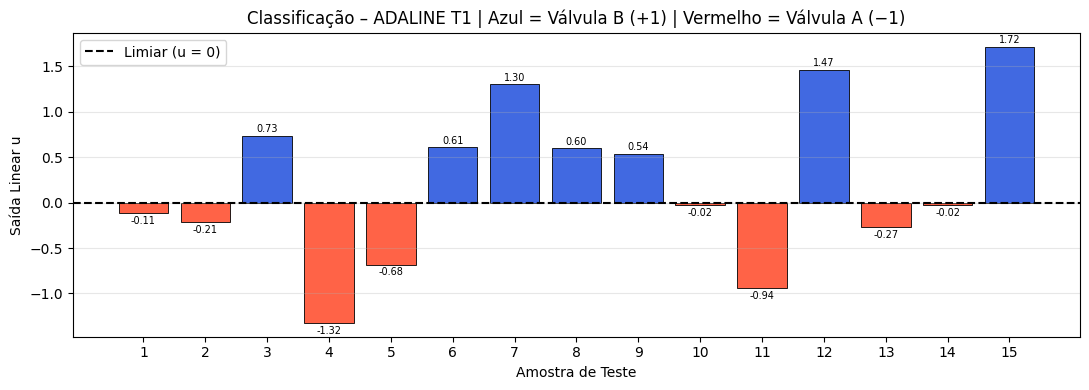

Gráfico salvo: classificacao_teste_T1.png


In [ ]:
cores = ['royalblue' if y >= 0 else 'tomato' for y in y_net_t1]

plt.figure(figsize=(11, 4))
plt.bar(range(1, N_teste + 1), y_net_t1, color=cores, edgecolor='k', linewidth=0.6)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--', label='Limiar (u = 0)')

for j, v in enumerate(y_net_t1):
    plt.text(j + 1, v + (0.04 if v >= 0 else -0.12), f"{v:.2f}",
             ha='center', fontsize=7)

plt.xlabel('Amostra de Teste')
plt.ylabel('Saída Linear u')
plt.title('Classificação – ADALINE T1 | Azul = Válvula B (+1) | Vermelho = Válvula A (−1)')
plt.xticks(range(1, N_teste + 1))
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('classificacao_teste_T1.png', dpi=150)
plt.show()
print("Gráfico salvo: classificacao_teste_T1.png")

## Resumo Final

In [ ]:
print("=" * 65)
print("RESUMO – ADALINE: CLASSIFICAÇÃO DE VÁLVULAS INDUSTRIAIS")
print("=" * 65)
print(f"η = {eta}  |  ε = {epsilon:.0e}  |  N_treino = {N}  |  N_teste = {N_teste}")
print()

for r in resultados:
    wi, wf = r['w_inicial'], r['w_final']
    pred = np.where(X @ wf >= 0, 1, -1)
    acc  = np.mean(pred == d) * 100
    fmt  = lambda v: f"{v:.4f}"
    print(f"T{r['T']} | Épocas: {r['epocas']:4d} | EQM: {r['eqm_final']:.6f} | Acurácia: {acc:.1f}%")
    print(f"   w_ini = [{', '.join(map(fmt, wi))}]")
    print(f"   w_fim = [{', '.join(map(fmt, wf))}]")
    print()

RESUMO – ADALINE: CLASSIFICAÇÃO DE VÁLVULAS INDUSTRIAIS
η = 0.0025  |  ε = 1e-06  |  N_treino = 35  |  N_teste = 15

T1 | Épocas:  831 | EQM: 0.350132 | Acurácia: 94.3%
   w_ini = [0.7713, 0.0208, 0.6336, 0.7488, 0.4985]
   w_fim = [1.6357, 1.2855, 1.5948, -0.1695, -1.1508]

T2 | Épocas:  819 | EQM: 0.350132 | Acurácia: 94.3%
   w_ini = [0.5881, 0.8977, 0.8915, 0.8158, 0.0359]
   w_fim = [1.6356, 1.2857, 1.5950, -0.1691, -1.1509]

T3 | Épocas:  814 | EQM: 0.350132 | Acurácia: 94.3%
   w_ini = [0.6441, 0.3807, 0.6630, 0.1637, 0.9626]
   w_fim = [1.6357, 1.2854, 1.5946, -0.1698, -1.1507]

T4 | Épocas:  826 | EQM: 0.350132 | Acurácia: 94.3%
   w_ini = [0.4077, 0.0554, 0.7885, 0.2873, 0.4504]
   w_fim = [1.6358, 1.2855, 1.5948, -0.1697, -1.1508]

T5 | Épocas:  841 | EQM: 0.350132 | Acurácia: 94.3%
   w_ini = [0.4946, 0.2281, 0.2555, 0.3963, 0.3773]
   w_fim = [1.6356, 1.2855, 1.5947, -0.1696, -1.1508]

